In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.callbacks import EvalCallback
import torch
import random
import os

# --- CONFIGURATION ---
CONFIG = {
    "WINDOW_SIZE": 60,       
    "TX_COST_BPS": 0.0010,   
    "RISK_AVERSION": 4.0,    
    "REBALANCE_DAYS": 20,
    # Strategy Params (Winner from Optimization)
    "PANIC_VOL": 0.0209,      
    "STRONG_TREND": 0.0065,
    "REBALANCE_THRESHOLD": 0.05,
    "COOLDOWN_DAYS": 3
}

# --- REPRODUCIBILITY ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
os.makedirs("./logs/", exist_ok=True) # Folder for best model
print("✓ Config Loaded.")

✓ Config Loaded.


In [9]:
import numpy as np
import pandas as pd

class SOTAFeatureEngineer:
    def preprocess_data(self, df):
        # 1. Clean Data (Forward Fill first to preserve last known price)
        data = df.copy().ffill().bfill()
        
        asset_cols = [c for c in data.columns if c != 'QQQ']
        
        # 2. Log Returns
        log_ret = np.log(data / data.shift(1)).fillna(0)
        
        # 3. Robust Features (Stationary)
        # Volatility Ratio: Is current vol expanding relative to recent history?
        # Range is roughly [0, 3] naturally. No normalization needed.
        vol_20 = log_ret.rolling(20).std()
        vol_60 = log_ret.rolling(60).std()
        vol_ratio = (vol_20 / (vol_60 + 1e-8)).clip(0, 3)
        
        # Relative Strength (Alpha) vs Benchmark
        # Rolling Z-Score of relative performance
        rel_perf = log_ret[asset_cols].sub(log_ret['QQQ'], axis=0)
        rel_str = (rel_perf.rolling(60).mean() / (rel_perf.rolling(60).std() + 1e-8)).clip(-3, 3)
        
        # Correlation (Diversification signal)
        corr = log_ret[asset_cols].rolling(60).corr(log_ret['QQQ']).fillna(0)
        
        # Price Momentum (Z-Score)
        roll_mean = log_ret[asset_cols].rolling(60).mean()
        roll_std = log_ret[asset_cols].rolling(60).std()
        mom_z = ((log_ret[asset_cols] - roll_mean) / (roll_std + 1e-8)).clip(-3, 3)

        # Stack Features
        features_list = [
            mom_z.values,                   # 0: Momentum Z-Score
            vol_ratio[asset_cols].values,   # 1: Volatility Expansion
            rel_str.values,                 # 2: Alpha Z-Score
            corr.values,                    # 3: Correlation
            log_ret[asset_cols].values * 100 # 4: Raw Returns (Scaled)
        ]
        
        features = np.stack(features_list, axis=-1)
        # Handle initial NaNs from rolling windows
        features = np.nan_to_num(features)
        
        return features.astype(np.float32), data[asset_cols].values, data['QQQ'].values, asset_cols

def get_data():
    from datetime import datetime
    tickers = ['NVDA', 'MU', 'AAPL', 'AMD', 'ASML', 'MSFT', 'GOOG', 'QQQ']
    print(f"📥 Downloading {len(tickers)} assets...")
    try:
        # Explicitly set auto_adjust=False to ensure 'Adj Close' is returned
        # group_by='column' ensures we can select 'Adj Close' easily
        raw_data = yf.download(tickers, start="2015-01-01", end=datetime.now().strftime("%Y-%m-%d"), auto_adjust=False, group_by='column')
        
        if 'Adj Close' in raw_data.columns:
             data = raw_data['Adj Close']
        elif isinstance(raw_data.columns, pd.MultiIndex):
             # Fallback: try to find Adj Close in levels or just take Close if Adj Close missing
             data = raw_data.xs('Adj Close', level=0, axis=1, drop_level=True)
        else:
             # If flat and no Adj Close, maybe just Close?
             data = raw_data['Close']
             
        if data.empty: raise ValueError('Data is empty')
        
        # Ensure we have a flat index (Tickers as columns)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(-1)
            
        return data.dropna()
    except Exception as e:
        print(f"⚠️ Data Download Failed or Empty. Check API. Error: {e}")
        return pd.DataFrame()
        

In [10]:
df = get_data()
# Initialize
engineer = SOTAFeatureEngineer()
features, prices, benchmark, ticker_names = engineer.preprocess_data(df)
print("✓ Features Engineered (Stationary).")

[*********************100%***********************]  8 of 8 completed

📥 Downloading 8 assets...
✓ Features Engineered (Stationary).


In [11]:
import gymnasium as gym
from gymnasium import spaces

class SOTAEnv(gym.Env):
    def __init__(self, price_data, features_data, benchmark_data, initial_balance=100_000, training_mode=True):
        super().__init__()
        self.prices = price_data
        self.features = features_data
        self.benchmark = benchmark_data
        self.n_assets = self.prices.shape[1]
        self.lookback = CONFIG["WINDOW_SIZE"]
        self.initial_balance = initial_balance
        self.training_mode = training_mode # Flag to control reset behavior
        
        # FIX: Finite but large bounds for Softmax to allow 0.0 weights
        self.action_space = spaces.Box(low=-20, high=20, shape=(self.n_assets + 1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-10, high=10, shape=(self.lookback, self.n_assets, self.features.shape[2]), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        if self.training_mode:
            # Random Start for Training
            max_start = len(self.prices) - CONFIG["REBALANCE_DAYS"] - 5
            if max_start > self.lookback:
                self.curr_step = np.random.randint(self.lookback, max_start)
            else:
                self.curr_step = self.lookback
        else:
            # Deterministic Start for Testing (Start immediately after lookback)
            self.curr_step = self.lookback
            
        self.cash = float(self.initial_balance)
        self.shares = np.zeros(self.n_assets)
        self.portfolio_value = float(self.initial_balance)
        self.history_nav = [self.portfolio_value]
        
        return self._get_obs(), {}

    def step(self, action):
        # SOTA Softmax (Stable)
        exp_action = np.exp(action - np.max(action))
        weights = exp_action / np.sum(exp_action)
        
        # Execute
        current_p = self.prices[self.curr_step]
        target_val = self.portfolio_value * weights[:-1]
        current_val = self.shares * current_p
        
        cost = np.sum(np.abs(target_val - current_val)) * CONFIG["TX_COST_BPS"]
        self.cash = (self.portfolio_value * weights[-1]) - cost
        self.shares = target_val / current_p
        
        # Time Skip
        nav_path = []
        steps = min(CONFIG["REBALANCE_DAYS"], len(self.prices) - self.curr_step - 1)
        
        for _ in range(steps):
            self.curr_step += 1
            # Recalculate Value
            val = self.cash + np.sum(self.shares * self.prices[self.curr_step])
            nav_path.append(val)
            
        self.portfolio_value = nav_path[-1] if len(nav_path) > 0 else self.portfolio_value
        self.history_nav.extend(nav_path)
        
        # --- CALMAR REWARD ---
        if len(nav_path) > 0:
            series = np.array(nav_path)
            ret = (series[-1] / series[0]) - 1
            # Max Drawdown in this specific window
            peak = np.maximum.accumulate(series)
            dd = (series - peak) / peak
            max_dd = np.abs(np.min(dd)) + 0.01 # Add epsilon
            
            reward = (ret * 100) / (max_dd * 5) # Scale for PPO
        else:
            reward = 0.0
            
        done = self.curr_step >= len(self.prices) - 2
        return self._get_obs(), reward, done, False, {}

    def _get_obs(self):
        # Slice the window
        return self.features[self.curr_step - self.lookback : self.curr_step]

In [12]:
import optuna

class DynamicManager:
    def __init__(self, benchmark_data):
        self.benchmark = benchmark_data
        
    def optimize_thresholds(self, n_trials=30):
        # We optimize using the Benchmark data to find the optimal "Safety Valve" settings
        # for the recent market regime.
        
        def objective(trial):
            p_vol = trial.suggest_float("panic_vol", 0.015, 0.040)
            p_trend = trial.suggest_float("strong_trend", 0.002, 0.015)
            
            # Vectorized Backtest on Benchmark
            b_rets = pd.Series(self.benchmark).pct_change().fillna(0)
            b_vol = b_rets.rolling(20).std()
            
            # Logic: If Vol > Panic -> Cash (0 return). Else -> Market
            # We want settings that saved us from recent crashes but kept upside
            signals = np.where(b_vol > p_vol, 0.0, b_rets)
            
            cum_ret = np.nancumsum(signals)
            total_ret = cum_ret[-1] if len(cum_ret) > 0 else 0
            
            # Calmar
            peak = np.maximum.accumulate(cum_ret)
            dd = peak - cum_ret
            max_dd = np.max(dd) if len(dd) > 0 else 1.0
            
            if max_dd == 0: return 0.0
            return total_ret / (max_dd + 0.01)

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        return study.best_params

In [13]:
def run_sota_rolling(full_prices, full_features, full_benchmark, ticker_names):
    TRAIN_SIZE = 252 * 2  # 2 Years
    TEST_SIZE = 60        # ~3 Months (Quarterly)
    
    # Start loop
    current_idx = 0
    history_nav = [100_000.0]
    model = None
    
    print(f"🚀 Starting Rolling Loop (Train: {TRAIN_SIZE}d, Test: {TEST_SIZE}d)")
    
    while current_idx + TRAIN_SIZE + TEST_SIZE < len(full_prices):
        # --- 1. Slicing ---
        train_start = current_idx
        train_end = current_idx + TRAIN_SIZE
        test_end = train_end + TEST_SIZE
        
        # Train Data
        p_train = full_prices[train_start:train_end]
        f_train = full_features[train_start:train_end]
        b_train = full_benchmark[train_start:train_end]
        
        # Test Data WITH CONTEXT (The Fix for ValueError)
        # We grab the lookback window preceding the test period
        test_context_start = train_end - CONFIG["WINDOW_SIZE"]
        p_test = full_prices[test_context_start:test_end]
        f_test = full_features[test_context_start:test_end]
        b_test = full_benchmark[test_context_start:test_end]
        
        # --- 2. Optimize Manager ---
        # Find best thresholds based on the RECENT training data (last 6 months of train set)
        mgr_data = b_train[-126:] 
        manager = DynamicManager(mgr_data)
        best_params = manager.optimize_thresholds(n_trials=20)
        
        # --- 3. Train Agent ---
        train_env = DummyVecEnv([lambda: SOTAEnv(p_train, f_train, b_train, training_mode=True)])
        
        if model is None:
            model = PPO("MlpPolicy", train_env, verbose=0, learning_rate=3e-4, ent_coef=0.01)
            model.learn(total_timesteps=15_000)
        else:
            model.set_env(train_env)
            model.learn(total_timesteps=5_000) # Fine-tune
            
        # --- 4. Execute Test Window ---
        # Start balance is carry-over from history
        current_cash = history_nav[-1]
        test_env = SOTAEnv(p_test, f_test, b_test, initial_balance=current_cash, training_mode=False)
        
        obs, _ = test_env.reset()
        done = False
        
        # Manual Step Loop to apply Manager Logic
        while not done:
            # Check Regime (using optimized params)
            # Use raw features from Env to determine regime
            # Feature Index 1 is Vol Ratio, Index 2 is Alpha
            # But we use the Benchmark Volatility for the "Safety Valve"
            curr_step_global = test_env.curr_step # Index inside p_test
            
            # Safety check for index
            if curr_step_global >= len(p_test): break
                
            b_slice = b_test[max(0, curr_step_global-20) : curr_step_global]
            vol = np.std(pd.Series(b_slice).pct_change()) if len(b_slice) > 1 else 0
            
            # Predict
            action, _ = model.predict(obs, deterministic=True)
            
            # OVERRIDE: Panic Mode
            if vol > best_params['panic_vol']:
                action[:] = -20.0 # Crush assets
                action[-1] = 20.0 # Boost cash
                
            # Step Env
            obs, _, done, _, _ = test_env.step(action)
            
        # Append Results (Skip the first index as it duplicates the carry-over)
        if len(test_env.history_nav) > 1:
            history_nav.extend(test_env.history_nav[1:])
            
        current_idx += TEST_SIZE
        print(f"✓ Window {train_end//TEST_SIZE}: Panic={best_params['panic_vol']:.4f} | NAV: ${history_nav[-1]:,.0f}")

    return history_nav



In [14]:
# Execute
print("Starting SOTA Simulation...")
nav_history = run_sota_rolling(prices, features, benchmark, ticker_names)

[I 2025-11-30 10:30:26,145] A new study created in memory with name: no-name-8d042bbd-7a47-4663-ac35-0bc32c4e3ad1
[I 2025-11-30 10:30:26,150] Trial 0 finished with value: 1.7601348825276852 and parameters: {'panic_vol': 0.015794866523570317, 'strong_trend': 0.008553382759675427}. Best is trial 0 with value: 1.7601348825276852.
[I 2025-11-30 10:30:26,151] Trial 1 finished with value: 1.7601348825276852 and parameters: {'panic_vol': 0.03708264404721269, 'strong_trend': 0.014479637814460282}. Best is trial 0 with value: 1.7601348825276852.


Starting SOTA Simulation...
🚀 Starting Rolling Loop (Train: 504d, Test: 60d)


[I 2025-11-30 10:30:26,152] Trial 2 finished with value: 1.7601348825276852 and parameters: {'panic_vol': 0.03860044522419379, 'strong_trend': 0.005226542497894331}. Best is trial 0 with value: 1.7601348825276852.
[I 2025-11-30 10:30:26,153] Trial 3 finished with value: 1.7601348825276852 and parameters: {'panic_vol': 0.025786273537224513, 'strong_trend': 0.009750610849528031}. Best is trial 0 with value: 1.7601348825276852.
[I 2025-11-30 10:30:26,154] Trial 4 finished with value: 1.7601348825276852 and parameters: {'panic_vol': 0.03614686189582105, 'strong_trend': 0.0030384856516231626}. Best is trial 0 with value: 1.7601348825276852.
[I 2025-11-30 10:30:26,155] Trial 5 finished with value: 1.7601348825276852 and parameters: {'panic_vol': 0.03131835142706266, 'strong_trend': 0.002965622631961723}. Best is trial 0 with value: 1.7601348825276852.
[I 2025-11-30 10:30:26,155] Trial 6 finished with value: 1.7601348825276852 and parameters: {'panic_vol': 0.01646339886870586, 'strong_trend':

✓ Window 8: Panic=0.0158 | NAV: $113,415


[I 2025-11-30 10:30:34,784] A new study created in memory with name: no-name-db81b339-d010-4053-88aa-7b42543dc87c
[I 2025-11-30 10:30:34,785] Trial 0 finished with value: 3.7249436584072786 and parameters: {'panic_vol': 0.03654748612307911, 'strong_trend': 0.01027210169319339}. Best is trial 0 with value: 3.7249436584072786.
[I 2025-11-30 10:30:34,785] Trial 1 finished with value: 3.7249436584072786 and parameters: {'panic_vol': 0.03574462628089688, 'strong_trend': 0.008551862396689841}. Best is trial 0 with value: 3.7249436584072786.
[I 2025-11-30 10:30:34,786] Trial 2 finished with value: 3.7249436584072786 and parameters: {'panic_vol': 0.03557656175640156, 'strong_trend': 0.006918855701837203}. Best is trial 0 with value: 3.7249436584072786.
[I 2025-11-30 10:30:34,787] Trial 3 finished with value: 3.7249436584072786 and parameters: {'panic_vol': 0.021830716548023123, 'strong_trend': 0.004338819053229528}. Best is trial 0 with value: 3.7249436584072786.
[I 2025-11-30 10:30:34,788] Tr

...

✓ Window 41: Panic=0.0366 | NAV: $946,262


[I 2025-11-30 10:31:50,439] A new study created in memory with name: no-name-9592e846-7789-49d1-bd7b-911e10a9fe0a
[I 2025-11-30 10:31:50,439] Trial 0 finished with value: -0.5445240530365708 and parameters: {'panic_vol': 0.022946292570867367, 'strong_trend': 0.003421208637973294}. Best is trial 0 with value: -0.5445240530365708.
[I 2025-11-30 10:31:50,440] Trial 1 finished with value: -0.6530593764392221 and parameters: {'panic_vol': 0.023659239860949536, 'strong_trend': 0.010668880463682986}. Best is trial 0 with value: -0.5445240530365708.
[I 2025-11-30 10:31:50,441] Trial 2 finished with value: -0.3575743075850964 and parameters: {'panic_vol': 0.03710118096387475, 'strong_trend': 0.01368685737622907}. Best is trial 2 with value: -0.3575743075850964.
[I 2025-11-30 10:31:50,442] Trial 3 finished with value: -0.6530593764392221 and parameters: {'panic_vol': 0.023737648560343556, 'strong_trend': 0.009088514221997555}. Best is trial 2 with value: -0.3575743075850964.
[I 2025-11-30 10:31:

✓ Window 42: Panic=0.0237 | NAV: $812,027


[I 2025-11-30 10:31:52,687] A new study created in memory with name: no-name-6ec99970-b6ba-4a15-a5db-b72d770456b3
[I 2025-11-30 10:31:52,688] Trial 0 finished with value: -0.22422640513648776 and parameters: {'panic_vol': 0.03219301008695955, 'strong_trend': 0.00745369693298184}. Best is trial 0 with value: -0.22422640513648776.
[I 2025-11-30 10:31:52,689] Trial 1 finished with value: 0.08382403805586762 and parameters: {'panic_vol': 0.019982673659599264, 'strong_trend': 0.005168563261722019}. Best is trial 1 with value: 0.08382403805586762.
[I 2025-11-30 10:31:52,690] Trial 2 finished with value: -0.23928909153482494 and parameters: {'panic_vol': 0.0318825831796423, 'strong_trend': 0.012047013595079729}. Best is trial 1 with value: 0.08382403805586762.
[I 2025-11-30 10:31:52,690] Trial 3 finished with value: -0.23928909153482494 and parameters: {'panic_vol': 0.030598024805052738, 'strong_trend': 0.011197058781159343}. Best is trial 1 with value: 0.08382403805586762.
[I 2025-11-30 10:3

✓ Window 43: Panic=0.0385 | NAV: $995,281
✓ Window 44: Panic=0.0172 | NAV: $1,240,466


🏆 FINAL PERFORMANCE REPORT


,Total Return,CAGR,Max Drawdown,Calmar Ratio,Sharpe Ratio,Sortino Ratio
SOTA AI,1140.47%,33.65%,-35.39%,0.95,268.79,1.34
Benchmark,289.49%,16.95%,-35.12%,0.48,145.68,0.73


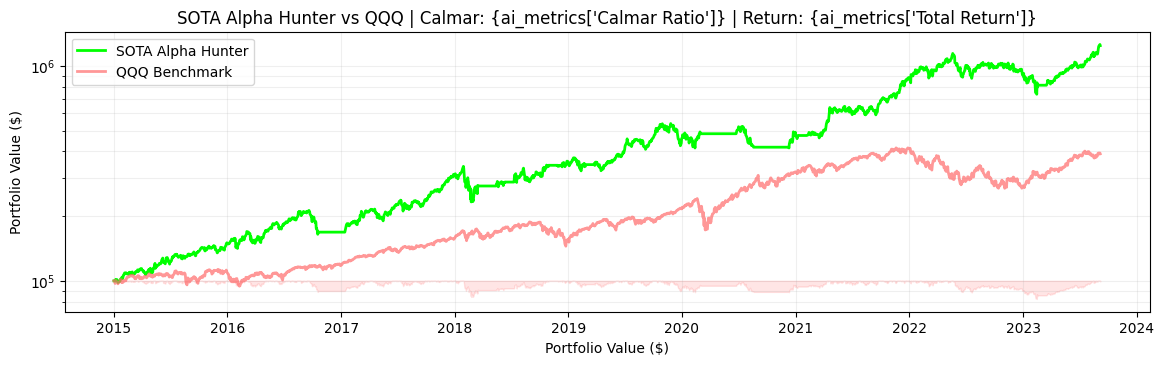

In [15]:
sim_dates = df.index[:len(nav_history)]
results = pd.DataFrame({
    "AI_Strategy": nav_history,
    "Benchmark": (benchmark[:len(nav_history)] / benchmark[0] * 100_000)
}, index=sim_dates)

# calc SOTA metrics
def calculate_metrics(series):
    ret = series.pct_change().fillna(0)
    # CAGR
    total_ret = (series.iloc[-1] / series.iloc[0] - 1)
    days = (series.index[-1] - series.index[0]).days
    cagr = (1 + total_ret) ** (365/days) - 1
    # Max Drawdown
    peak = series.cummax()
    drawdown = (series - peak) / peak
    max_dd = drawdown.min()
    # Calmar
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    # Sharpe (Risk Free Rate assumed 0 for simplicity)
    rfr = 0.04
    sharpe = (cagr - rfr) / ret.std() * np.sqrt(252)
    # Sortino (Downside Volatility only)
    downside_vol = ret[ret < 0].std() * np.sqrt(252)
    sortino = (cagr - rfr) / downside_vol if downside_vol > 0 else 0
    
    return {
        "Total Return": f"{total_ret*100:.2f}%",
        "CAGR": f"{cagr*100:.2f}%",
        "Max Drawdown": f"{max_dd*100:.2f}%",
        "Calmar Ratio": f"{calmar:.2f}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}"
    }

ai_metrics = calculate_metrics(results['AI_Strategy'])
bench_metrics = calculate_metrics(results['Benchmark'])

# 4. Display Metrics
print("="*50)
print("🏆 FINAL PERFORMANCE REPORT")
print("="*50)
metrics_df = pd.DataFrame([ai_metrics, bench_metrics], index=['SOTA AI', 'Benchmark'])
display(metrics_df)

# 5. Professional Visualization
plt.figure(figsize=(14, 8))

# Main Equity Curve
plt.subplot(2, 1, 1)
plt.plot(results['AI_Strategy'], label='SOTA Alpha Hunter', color='#00FF00', linewidth=2)
plt.plot(results['Benchmark'], label='QQQ Benchmark', color='#FF6B6B', linewidth=2, alpha=0.7)

# Drawdown Underlay (To visualize risk)
peak_ai = results['AI_Strategy'].cummax()
dd_ai = (results['AI_Strategy'] - peak_ai) / peak_ai
plt.fill_between(results.index, dd_ai * 50000 + 100000, 100000, color='red', alpha=0.1)

plt.title("SOTA Alpha Hunter vs QQQ | Calmar: {ai_metrics['Calmar Ratio']} | Return: {ai_metrics['Total Return']}")
plt.ylabel("Portfolio Value ($)")
plt.yscale('log')  # Log scale is standard for long-term growth comparison
plt.xlabel("Portfolio Value ($)")
plt.legend(loc='upper left')
plt.grid(True, which='both', alpha=0.2)

plt.show()
